In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report
from imblearn.over_sampling import RandomOverSampler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# Load the dataset from a CSV file into a pandas DataFrame.
def load_data(file_name) : 
    data = pd.read_csv(file_name)
    return data

# Calculate the number of missing entries per column.
def check_if_values_are_missing(data) : 
    return data.isnull().sum()






/Users/vinamravinay/Simplilearn_Python/deeplearning_python/.venv-tf/bin/python


In [107]:
def check_if_values_are_missing(data) : 
    return data.isnull().sum()

# Generate a missing data profile with counts and percentage for each column.
def create_missing_data_report(data) : 
    missing_count = data.isnull().sum()
    missing_percent = (data.isnull().sum() / len(data)) * 100

    missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

    missing_report = missing_report[missing_report["missing_count"] > 0].sort_values(
        by="missing_percent", ascending=False
)

    return missing_report

In [108]:
## check for percentage of default vs payer in TARGET column
# Print class balance percentages for TARGET.
def check_target_distribution(data) :
    default_percent = (data["TARGET"].sum() / len(data)) * 100
    payer_percent = 100 - default_percent

    print(f"Percentage of defaulters (TARGET = 1): {default_percent:.2f}%")
    print(f"Percentage of payers (TARGET = 0): {payer_percent:.2f}%")


In [109]:
# Plotting the imbalance data in TARGET column
# Show bar chart for the TARGET class distribution.
def plot_target_distribution(data) :
    plt.figure(figsize=(6, 4))
    data["TARGET"].value_counts().plot(kind="bar", color=["blue", "orange"])
    plt.title("Distribution of TARGET Variable")
    plt.xlabel("TARGET")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [111]:
## handle columns with missing values
## drop columns with more than 50% missing values
## fill numeric columns with median and categorical columns with mode
# Clean dataset: drop high-missing columns, then impute remaining nulls.
def handle_missing_values(data, missing_report):
    cols_to_drop = missing_report[missing_report["missing_percent"] > 50].index

    # Drop columns with more than 50% missing values
    data = data.drop(columns=cols_to_drop)

    num_cols = data.select_dtypes(include=["number"]).columns
    cat_cols = data.select_dtypes(include=["object"]).columns

    for col in num_cols:
        if col != "TARGET":
            data[col] = data[col].fillna(data[col].median())

    for col in cat_cols:
        data[col] = data[col].fillna(data[col].mode()[0])

    print(data.isnull().sum()[data.isnull().sum() > 0])
    return data

In [112]:
##encode categorical columns and scale numeric features
# Encode categorical columns in-place and return label encoders for inverse transform.
def encode_and_scale_features(data):
    label_encoders = {}
    for col in data.select_dtypes(include=["object"]).columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        label_encoders[col] = le
    return data, label_encoders


# split features and target variable
# Separate data into X features and y target label.
def split_data(data):
    X = data.drop(columns=["TARGET"])
    y = data["TARGET"]
    return X, y


# balance the dataset using RandomOverSampler
# Perform class oversampling to fix target imbalance and report class counts.
def balance_data(X, y):
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y)

    print("Before balancing:")
    print(y.value_counts())

    print("\nAfter balancing:")
    print(pd.Series(y_resampled).value_counts())

    return X_resampled, y_resampled


# plot balanced data
# Visualize the class distribution after oversampling.
def plot_balanced_data(y_resampled):
    plt.figure(figsize=(6, 4))
    pd.Series(y_resampled).value_counts().plot(kind="bar", color=["blue", "orange"])
    plt.title("Distribution of TARGET Variable After Balancing")
    plt.xlabel("TARGET")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

    plt.show()

In [117]:
# create train test split
# Stratified train/test split to preserve target class distribution.
def create_train_test_split(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test


In [118]:
# scale features
# Standardize features so each column has mean=0 and variance=1.
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# build deep learning model using Keras Sequential API
# Define network layers and train with early stopping.
def build_deep_learning_model(X_train, y_train):
    model = Sequential()
    model.add(Dense(128, activation="relu", input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    return history, model


In [119]:
# predict and evaluate the model
# Compute predictions and print classification metrics for test data.
def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))



In [120]:
# calculate sensitivity, ROC AUC score, and plot ROC curve
# Compute confusion matrix, sensitivity, ROC AUC, and show ROC plot for test data.
def calculate_metrics(model, X_test, y_test):
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    roc_auc = roc_auc_score(y_test, y_pred_prob)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{cm}")

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()


In [121]:
def main():
    data = load_data("loan_data.csv")

    missing_report = create_missing_data_report(data)
    print(missing_report)

    data = handle_missing_values(data, missing_report)

    if "SK_ID_CURR" in data.columns:
        data = data.drop(columns=["SK_ID_CURR"])

    print("Remaining NaNs after cleaning:", data.isnull().sum().sum())

    check_target_distribution(data)
    plot_target_distribution(data)

    data, label_encoders = encode_and_scale_features(data)

    X, y = split_data(data)

    X_train, X_test, y_train, y_test = create_train_test_split(X, y)

    X_train_resampled, y_train_resampled = balance_data(X_train, y_train)
    plot_balanced_data(y_train_resampled)

    X_train_scaled, X_test_scaled = scale_features(X_train_resampled, X_test)

    history, model = build_deep_learning_model(X_train_scaled, y_train_resampled)

    evaluate_model(model, X_test_scaled, y_test)
    calculate_metrics(model, X_test_scaled, y_test)

    


                          missing_count  missing_percent
COMMONAREA_MEDI                  214865        69.872297
COMMONAREA_AVG                   214865        69.872297
COMMONAREA_MODE                  214865        69.872297
NONLIVINGAPARTMENTS_MEDI         213514        69.432963
NONLIVINGAPARTMENTS_MODE         213514        69.432963
...                                 ...              ...
EXT_SOURCE_2                        660         0.214626
AMT_GOODS_PRICE                     278         0.090403
AMT_ANNUITY                          12         0.003902
CNT_FAM_MEMBERS                       2         0.000650
DAYS_LAST_PHONE_CHANGE                1         0.000325

[67 rows x 2 columns]


/var/folders/0g/q0gbscdx7fs0zbm0zxtjhn700000gn/T/ipykernel_40799/891017687.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=["object"]).columns


Series([], dtype: int64)
Remaining NaNs after cleaning: 0
Percentage of defaulters (TARGET = 1): 8.07%
Percentage of payers (TARGET = 0): 91.93%


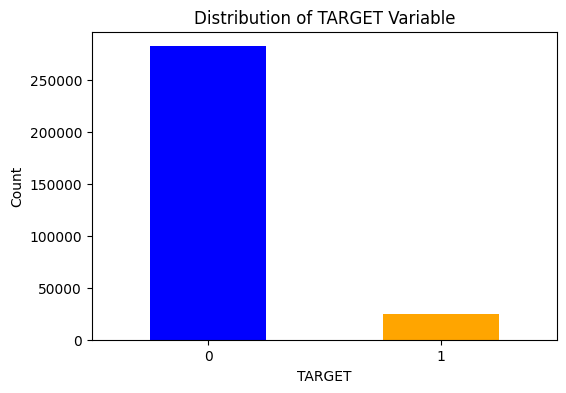

/var/folders/0g/q0gbscdx7fs0zbm0zxtjhn700000gn/T/ipykernel_40799/1573565611.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include=["object"]).columns:


Before balancing:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After balancing:
TARGET
0    226148
1    226148
Name: count, dtype: int64


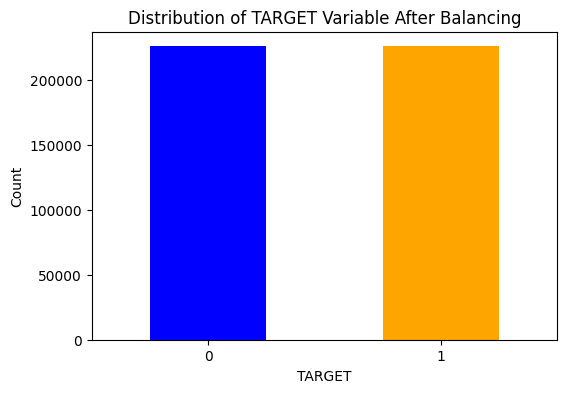

Epoch 1/20


/Users/vinamravinay/Simplilearn_Python/deeplearning_python/.venv-tf/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11308/11308 ━━━━━━━━━━━━━━━━━━━━ 5s 415us/step - accuracy: 0.6956 - loss: 0.5819 - val_accuracy: 0.4542 - val_loss: 0.8025
Epoch 2/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 5s 411us/step - accuracy: 0.7023 - loss: 0.5712 - val_accuracy: 0.4554 - val_loss: 0.7901
Epoch 3/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 5s 416us/step - accuracy: 0.7046 - loss: 0.5658 - val_accuracy: 0.4589 - val_loss: 0.7675
Epoch 4/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 5s 437us/step - accuracy: 0.7067 - loss: 0.5617 - val_accuracy: 0.4406 - val_loss: 0.7850
Epoch 5/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 5s 414us/step - accuracy: 0.7085 - loss: 0.5570 - val_accuracy: 0.4589 - val_loss: 0.7716
Epoch 6/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 5s 413us/step - accuracy: 0.7104 - loss: 0.5541 - val_accuracy: 0.4689 - val_loss: 0.7254
Epoch 7/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 5s 430us/step - accuracy: 0.7119 - loss: 0.5510 - val_accuracy: 0.4445 - val_loss: 0.7693
Epoch 8/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 5s 426us/step - accuracy: 0.7

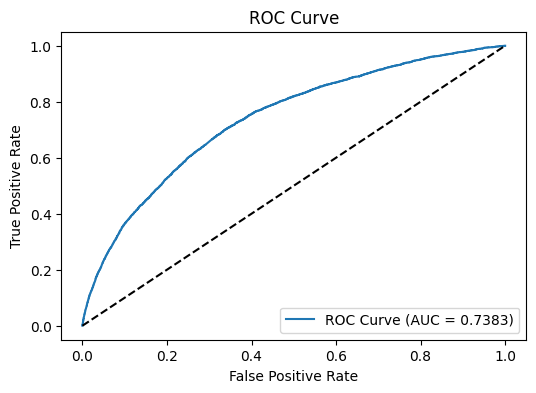

In [122]:
main()
